# EN3150 Assignment 03: Resource-Constrained Image Classification

This notebook compares standard and lightweight convolutional neural
networks for EuroSAT RGB land-cover classification.

- **Input:** A 64 × 64 RGB satellite image.
- **Target:** One of 10 land-cover classes.
- **Custom models:** A standard CNN and a depthwise-separable CNN.
- **Pretrained models:** MobileNetV2 and ShuffleNetV2.
- **Evaluation:** Classification performance, model size and computational cost.

## 1. Environment verification

We first check the active Python environment, package versions and
PyTorch GPU availability. This establishes the hardware and software
used for the experiments.

In [1]:
import sys
import platform
from importlib.metadata import version

import torch
import torchvision

print("Python executable:", sys.executable)
print("Python version:", platform.python_version())
print("Operating system:", platform.platform())

print("\nPackage versions:")
for package in [
    "torch",
    "torchvision",
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "Pillow",
]:
    print(f"  {package}: {version(package)}")

print("\nGPU information:")
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

if device.type == "cuda":
    properties = torch.cuda.get_device_properties(0)
    print("GPU:", properties.name)
    print(f"Total GPU memory: {properties.total_memory / 1024**3:.2f} GiB")

# Verify that a small tensor operation works on the selected device.
x = torch.ones((2, 3), device=device)
print("\nDevice computation check:", (x * 2).sum().item())

Python executable: c:\Users\hrana\anaconda3\envs\ml_env_fixed\python.exe
Python version: 3.11.14
Operating system: Windows-10-10.0.26200-SP0

Package versions:
  torch: 2.5.1
  torchvision: 0.20.1
  numpy: 1.26.4
  pandas: 2.3.3
  scikit-learn: 1.8.0
  matplotlib: 3.10.9
  Pillow: 12.3.0

GPU information:
PyTorch CUDA build: 11.8
CUDA available: True
Selected device: cuda
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design
Total GPU memory: 4.00 GiB

Device computation check: 12.0


## 2. Dataset location

I keep the original EuroSAT images in `data/raw/eurosat/2750`.
I use paths relative to the project folder so the notebook can run
on another computer without changing a personal file path.

In [2]:
from pathlib import Path

# I support running the notebook from the project folder or notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# I set the folders used to download and load the dataset.
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
ARCHIVE_PATH = RAW_DATA_DIR / "eurosat" / "EuroSAT.zip"
DATA_ROOT = RAW_DATA_DIR / "eurosat" / "2750"

print("Project folder:", PROJECT_ROOT)
print("Image folder:", DATA_ROOT)

Project folder: d:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN
Image folder: d:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\data\raw\eurosat\2750


### 2.1 Load the dataset

I downloaded the EuroSAT RGB archive through my browser.
I check its checksum before extracting it to confirm the download is complete.

I then load the original images without resizing or augmentation.

In [3]:
import hashlib
from zipfile import ZipFile
from torchvision.datasets import EuroSAT

if not ARCHIVE_PATH.is_file():
    raise FileNotFoundError(
        f"I need to place EuroSAT.zip here:\n{ARCHIVE_PATH}"
    )

# I check the archive against the checksum used by torchvision.
expected_md5 = "c8fa014336c82ac7804f0398fcb19387"

checksum = hashlib.md5()
with ARCHIVE_PATH.open("rb") as file:
    for chunk in iter(lambda: file.read(1024 * 1024), b""):
        checksum.update(chunk)

if checksum.hexdigest() != expected_md5:
    raise ValueError("The checksum does not match. Download the archive again.")

print("Archive checksum verified.")

# I extract the images if the dataset folder is not already present.
if not DATA_ROOT.is_dir():
    with ZipFile(ARCHIVE_PATH) as archive:
        archive.extractall(ARCHIVE_PATH.parent)
    print("Dataset extracted.")

# I load the images without applying any transforms.
dataset = EuroSAT(
    root=str(RAW_DATA_DIR),
    download=False,
    transform=None,
)

CLASS_NAMES = dataset.classes

print("\nTotal images:", len(dataset))
print("Number of classes:", len(CLASS_NAMES))

print("\nClass labels:")
for class_name, label in dataset.class_to_idx.items():
    print(f"  {label}: {class_name}")

# I check the size, colour mode and label of one image.
image, label = dataset[0]

print("\nFirst image:")
print("Size (width, height):", image.size)
print("Colour mode:", image.mode)
print("Label:", label)
print("Class:", CLASS_NAMES[label])

Archive checksum verified.

Total images: 27000
Number of classes: 10

Class labels:
  0: AnnualCrop
  1: Forest
  2: HerbaceousVegetation
  3: Highway
  4: Industrial
  5: Pasture
  6: PermanentCrop
  7: Residential
  8: River
  9: SeaLake

First image:
Size (width, height): (64, 64)
Colour mode: RGB
Label: 0
Class: AnnualCrop


## 3. Data exploration

### 3.1 Class distribution

I count the images in each class to check whether the dataset is balanced.
I also calculate each class's percentage of the total dataset.



,class_name,image_count,percentage
0,AnnualCrop,3000,11.11
1,Forest,3000,11.11
2,HerbaceousVegetation,3000,11.11
3,Highway,2500,9.26
4,Industrial,2500,9.26
5,Pasture,2000,7.41
6,PermanentCrop,2500,9.26
7,Residential,3000,11.11
8,River,2500,9.26
9,SeaLake,3000,11.11


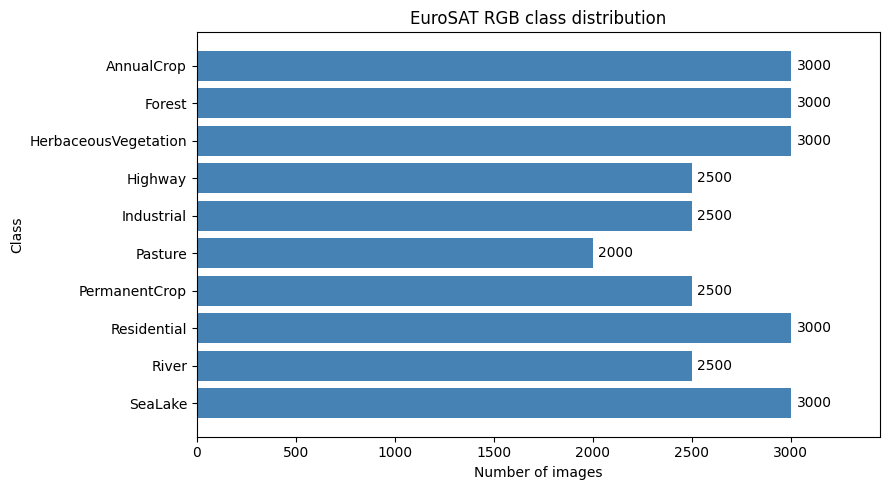

Largest class: 3,000 images
Smallest class: 2,000 images
Largest-to-smallest ratio: 1.50


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# I create one row for each image and its class label.
image_df = pd.DataFrame(dataset.samples, columns=["path", "label"])
image_df["class_name"] = image_df["label"].map(
    dict(enumerate(CLASS_NAMES))
)

# I count the images in each class.
class_counts = (
    image_df.groupby("class_name")
    .size()
    .reindex(CLASS_NAMES)
    .rename("image_count")
    .reset_index()
)

class_counts["percentage"] = (
    100 * class_counts["image_count"] / len(image_df)
).round(2)

display(class_counts)

# I plot the counts to compare the classes.
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    class_counts["class_name"],
    class_counts["image_count"],
    color="steelblue",
)

ax.bar_label(bars, padding=4)
ax.set_xlabel("Number of images")
ax.set_ylabel("Class")
ax.set_title("EuroSAT RGB class distribution")
ax.set_xlim(0, class_counts["image_count"].max() * 1.15)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

largest = class_counts["image_count"].max()
smallest = class_counts["image_count"].min()

print(f"Largest class: {largest:,} images")
print(f"Smallest class: {smallest:,} images")
print(f"Largest-to-smallest ratio: {largest / smallest:.2f}")

The class sizes range from 2,000 to 3,000 images. Pasture is the smallest
class, and the largest-to-smallest ratio is 1.5.

I use a stratified split to keep similar class proportions in the training,
validation and test sets. I start without class weighting and later check
per-class precision and recall to see whether smaller classes perform worse.

### 3.2 Sample images

I display three images from each class to inspect their colours, textures
and shapes. I use a fixed random seed so the same examples appear when
I rerun this cell.

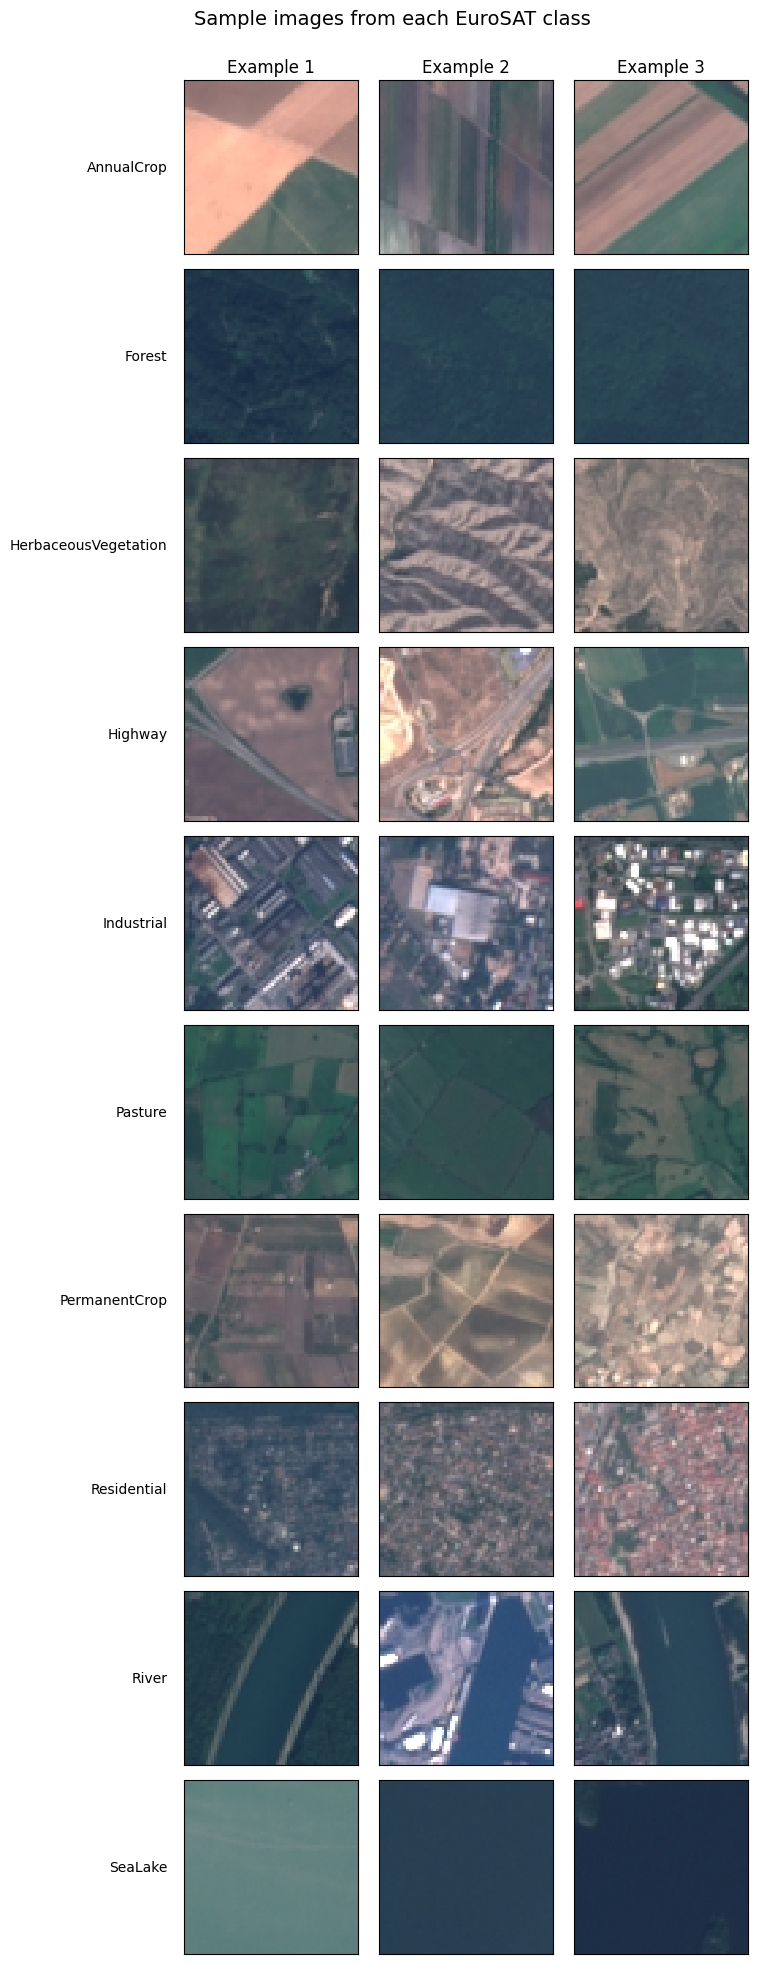

In [6]:
from PIL import Image

# I use a fixed seed to select the same examples each time.
SEED = 42
rng = np.random.default_rng(SEED)
samples_per_class = 3

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    samples_per_class,
    figsize=(8, 20),
)

for label, class_name in enumerate(CLASS_NAMES):
    class_indices = image_df.index[
        image_df["label"] == label
    ].to_numpy()

    selected_indices = rng.choice(
        class_indices,
        size=samples_per_class,
        replace=False,
    )

    for column, index in enumerate(selected_indices):
        image_path = image_df.loc[index, "path"]

        with Image.open(image_path) as image:
            axes[label, column].imshow(image, interpolation="nearest")

        axes[label, column].set_xticks([])
        axes[label, column].set_yticks([])

        if column == 0:
            axes[label, column].set_ylabel(
                class_name,
                rotation=0,
                ha="right",
                va="center",
                labelpad=12,
            )

        if label == 0:
            axes[label, column].set_title(f"Example {column + 1}")

fig.suptitle("Sample images from each EuroSAT class", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### 3.3 Image quality checks

I check that every image can be opened and fully read.
I also check the original image dimensions and colour modes.

This helps me find damaged files or unexpected image formats before
splitting the dataset.

In [7]:
from tqdm.auto import tqdm

image_checks = []

# I read every image and record its original size and colour mode.
for image_path in tqdm(image_df["path"], desc="Checking images"):
    record = {
        "path": image_path,
        "width": None,
        "height": None,
        "mode": None,
        "error": None,
    }

    try:
        with Image.open(image_path) as image:
            image.load()
            record["width"], record["height"] = image.size
            record["mode"] = image.mode

    except (OSError, ValueError) as error:
        record["error"] = str(error)

    image_checks.append(record)

quality_df = pd.DataFrame(image_checks)
valid_images = quality_df[quality_df["error"].isna()]
unreadable_images = quality_df[quality_df["error"].notna()]

print("Images checked:", len(quality_df))
print("Readable images:", len(valid_images))
print("Unreadable images:", len(unreadable_images))

print("\nImage sizes and colour modes:")
display(
    valid_images.groupby(["width", "height", "mode"])
    .size()
    .reset_index(name="image_count")
)

unexpected_images = valid_images[
    (valid_images["width"] != 64)
    | (valid_images["height"] != 64)
    | (valid_images["mode"] != "RGB")
]

print("Images with unexpected size or colour mode:", len(unexpected_images))

if not unreadable_images.empty:
    display(unreadable_images.head(10))

if not unexpected_images.empty:
    display(unexpected_images.head(10))

Checking images:   0%|          | 0/27000 [00:00<?, ?it/s]

Images checked: 27000
Readable images: 27000
Unreadable images: 0

Image sizes and colour modes:


,width,height,mode,image_count
0,64,64,RGB,27000


Images with unexpected size or colour mode: 0


All 27,000 images are readable and have a resolution of 64 × 64 pixels
with three RGB channels. I found no unreadable images or unexpected formats,
so no resizing is needed to meet the assignment's resolution limit.

From the displayed examples, I find some classes easier to recognise than
others. HerbaceousVegetation is less clear to me. I will later use the
confusion matrix to check which classes are difficult for the models.

### 3.4 Exact duplicate checks

I compare image pixels to find exact duplicates, even if their filenames
are different. I also check whether identical images have different labels.

This check finds identical images, but it does not detect similar scenes
or nearby geographic locations.

In [8]:
import hashlib

# I check that all images passed the earlier quality checks.
assert unreadable_images.empty, "Unreadable images need to be checked first."
assert unexpected_images.empty, "Unexpected image formats need to be checked first."

pixel_hashes = []

# I hash the original RGB pixels without changing the images.
for image_path in tqdm(image_df["path"], desc="Checking duplicates"):
    with Image.open(image_path) as image:
        pixel_hash = hashlib.sha256(image.tobytes()).hexdigest()
        pixel_hashes.append(pixel_hash)

image_df["pixel_hash"] = pixel_hashes

# I include every image belonging to a duplicate group.
duplicate_images = image_df[
    image_df.duplicated("pixel_hash", keep=False)
].copy()

duplicate_groups = duplicate_images["pixel_hash"].nunique()
extra_copies = len(image_df) - image_df["pixel_hash"].nunique()

# I check whether any identical images have different class labels.
labels_per_hash = image_df.groupby("pixel_hash")["label"].nunique()
conflicting_hashes = labels_per_hash[labels_per_hash > 1].index

print("Unique images:", image_df["pixel_hash"].nunique())
print("Duplicate groups:", duplicate_groups)
print("Images in duplicate groups:", len(duplicate_images))
print("Extra duplicate copies:", extra_copies)
print("Groups with conflicting labels:", len(conflicting_hashes))

if not duplicate_images.empty:
    display(
        duplicate_images.sort_values("pixel_hash")[
            ["path", "class_name", "pixel_hash"]
        ].head(20)
    )

Checking duplicates:   0%|          | 0/27000 [00:00<?, ?it/s]

Unique images: 27000
Duplicate groups: 0
Images in duplicate groups: 0
Extra duplicate copies: 0
Groups with conflicting labels: 0


I found 27,000 unique images with no exact duplicates or conflicting labels.
I keep all images for the dataset split.

## 4. Dataset splitting

I split the dataset into 70% training, 15% validation and 15% testing.
I use stratification to preserve the class proportions and a fixed random
seed to make the split reproducible.

I save the image lists so all models and team members can use the same
splits. I use validation results for tuning and keep the test set for
final evaluation.

In [9]:
from sklearn.model_selection import train_test_split

SEED = 42

# I first separate 70% for training and 30% for validation and testing.
train_df, remaining_df = train_test_split(
    image_df,
    test_size=0.30,
    stratify=image_df["label"],
    random_state=SEED,
)

# I divide the remaining images equally into validation and test sets.
val_df, test_df = train_test_split(
    remaining_df,
    test_size=0.50,
    stratify=remaining_df["label"],
    random_state=SEED,
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

# I check the sizes and confirm that the splits do not overlap.
assert (len(train_df), len(val_df), len(test_df)) == (18900, 4050, 4050)

train_paths = set(train_df["path"])
val_paths = set(val_df["path"])
test_paths = set(test_df["path"])

assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)
assert train_paths | val_paths | test_paths == set(image_df["path"])

# I compare the class counts across the three splits.
split_counts = pd.DataFrame({
    "train": train_df.groupby("class_name").size(),
    "validation": val_df.groupby("class_name").size(),
    "test": test_df.groupby("class_name").size(),
}).reindex(CLASS_NAMES)

display(split_counts)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))
print("No overlap between splits.")

# I save paths relative to the image folder, without copying the images.
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

for split_name, split_df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    split_df["relative_path"] = split_df["path"].map(
        lambda path: Path(path).relative_to(DATA_ROOT).as_posix()
    )

    split_df[
        ["relative_path", "label", "class_name", "pixel_hash"]
    ].to_csv(SPLIT_DIR / f"{split_name}.csv", index=False)

print("\nSplit lists saved to:", SPLIT_DIR)

,train,validation,test
class_name,,,
AnnualCrop,2100,450,450
Forest,2100,450,450
HerbaceousVegetation,2100,450,450
Highway,1750,375,375
Industrial,1750,375,375
Pasture,1400,300,300
PermanentCrop,1750,375,375
Residential,2100,450,450
River,1750,375,375


Training images: 18900
Validation images: 4050
Test images: 4050
No overlap between splits.

Split lists saved to: d:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\data\splits


The split contains 18,900 training images, 4,050 validation images and
4,050 test images, with no overlap. Each class follows the required
70/15/15 proportions.

I keep the original class distribution because the imbalance is mild.
I start with ordinary cross-entropy loss and check per-class results
during evaluation. If balancing is needed, I apply it only to the
training set.

## 5. Image preprocessing

### 5.1 Training-set mean and standard deviation

I scale pixel values from 0–255 to 0–1 and calculate the mean and standard
deviation for each RGB channel using only the training images.

I will use these values to normalize inputs to my custom CNNs.
I do not use validation or test images to calculate these values.
For the pretrained models, I will use the normalization expected by
their pretrained weights.

In [10]:
# I accumulate channel statistics using float64 for numerical precision.
channel_sum = np.zeros(3, dtype=np.float64)
channel_squared_sum = np.zeros(3, dtype=np.float64)
pixel_count = 0

for image_path in tqdm(train_df["path"], desc="Calculating RGB statistics"):
    with Image.open(image_path) as image:
        pixels = np.asarray(image, dtype=np.float64) / 255.0

    channel_sum += pixels.sum(axis=(0, 1))
    channel_squared_sum += (pixels ** 2).sum(axis=(0, 1))
    pixel_count += pixels.shape[0] * pixels.shape[1]

# I calculate the mean and population standard deviation per channel.
train_mean = channel_sum / pixel_count
channel_variance = channel_squared_sum / pixel_count - train_mean ** 2
train_std = np.sqrt(np.maximum(channel_variance, 0.0))

assert np.all(train_std > 0), "Each channel must have a nonzero standard deviation."

normalization_stats = pd.DataFrame({
    "channel": ["Red", "Green", "Blue"],
    "mean": train_mean,
    "std": train_std,
})

display(normalization_stats.round(6))
print("Training images used:", len(train_df))
print("Pixels per channel:", pixel_count)

Calculating RGB statistics:   0%|          | 0/18900 [00:00<?, ?it/s]

,channel,mean,std
0,Red,0.343901,0.202425
1,Green,0.379954,0.136683
2,Blue,0.407549,0.115408


Training images used: 18900
Pixels per channel: 77414400


### 5.2 Preprocessing and training augmentation

I keep the images at their original resolution of 64 × 64 pixels.

For training, I randomly flip images and rotate them by multiples of
90 degrees. These changes preserve the land-cover label while varying
the image orientation.

I convert images to tensors and normalize each channel using the
training-set mean and standard deviation. For validation and testing,
I apply only tensor conversion and normalization.

In [11]:
import random
from torchvision import transforms

# I define rotations that preserve the image size without interpolation.
class RandomQuarterTurn:
    def __call__(self, image):
        rotation = random.choice([
            None,
            Image.Transpose.ROTATE_90,
            Image.Transpose.ROTATE_180,
            Image.Transpose.ROTATE_270,
        ])
        return image.copy() if rotation is None else image.transpose(rotation)


# I separate augmentation so I can also preview it before normalization.
train_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    RandomQuarterTurn(),
])

normalize = transforms.Normalize(
    mean=train_mean.tolist(),
    std=train_std.tolist(),
)

train_transform = transforms.Compose([
    train_augmentation,
    transforms.ToTensor(),
    normalize,
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize,
])

# I check preprocessing on a training image.
with Image.open(train_df.iloc[0]["path"]) as image:
    original_image = image.convert("RGB")

train_tensor = train_transform(original_image)
eval_tensor = eval_transform(original_image)

print("Training tensor shape:", tuple(train_tensor.shape))
print("Evaluation tensor shape:", tuple(eval_tensor.shape))
print("Tensor data type:", train_tensor.dtype)
print("All training values finite:", torch.isfinite(train_tensor).all().item())
print("All evaluation values finite:", torch.isfinite(eval_tensor).all().item())

# I confirm that evaluation preprocessing gives the same result each time.
print(
    "Evaluation preprocessing is repeatable:",
    torch.equal(eval_tensor, eval_transform(original_image)),
)

Training tensor shape: (3, 64, 64)
Evaluation tensor shape: (3, 64, 64)
Tensor data type: torch.float32
All training values finite: True
All evaluation values finite: True
Evaluation preprocessing is repeatable: True


### 5.3 Augmentation preview

I compare an original training image with five randomly augmented versions.
I check that flips and rotations keep the full image and preserve its label.

I display these images before normalization to keep their original colours.

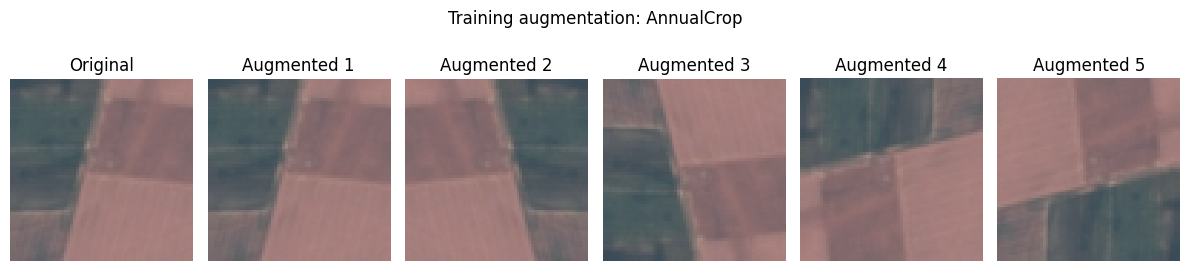

In [12]:
# I use a fixed seed to make this preview reproducible.
random.seed(SEED)
torch.manual_seed(SEED)

# I select an AnnualCrop image from the training set.
preview_row = train_df[train_df["class_name"] == "AnnualCrop"].iloc[0]

with Image.open(preview_row["path"]) as image:
    preview_image = image.convert("RGB")

fig, axes = plt.subplots(1, 6, figsize=(12, 3))

axes[0].imshow(preview_image, interpolation="nearest")
axes[0].set_title("Original")

# I show five independent applications of training augmentation.
for index in range(1, 6):
    augmented_image = train_augmentation(preview_image)
    axes[index].imshow(augmented_image, interpolation="nearest")
    axes[index].set_title(f"Augmented {index}")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"Training augmentation: {preview_row['class_name']}")
plt.tight_layout()
plt.show()

### 5.4 Datasets and data loaders

I create separate datasets for training, validation and testing.
Each sample returns a processed image and its integer class label.

I apply random augmentation only during training. I shuffle training
images and keep validation and test images in a fixed order.

I start with a batch size of 64. I use zero background workers for
compatibility with my Windows notebook.

In [13]:
from torch.utils.data import Dataset, DataLoader

# I load each image when it is requested rather than storing all images in RAM.
class EuroSATSplit(Dataset):
    def __init__(self, dataframe, transform):
        self.paths = dataframe["path"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        with Image.open(self.paths[index]) as image:
            image = image.convert("RGB")

        image = self.transform(image)
        label = self.labels[index]
        return image, label


# I set random seeds before creating the loaders.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

train_dataset = EuroSATSplit(train_df, train_transform)
val_dataset = EuroSATSplit(val_df, eval_transform)
test_dataset = EuroSATSplit(test_df, eval_transform)

BATCH_SIZE = 64
pin_memory = device.type == "cuda"

# I use a separate generator to control the training shuffle.
train_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=0,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

# I check one training batch without accessing the test images.
images, labels = next(iter(train_loader))

print("Dataset sizes:")
print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nTraining batch:")
print("Image shape:", tuple(images.shape))
print("Label shape:", tuple(labels.shape))
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("All image values finite:", torch.isfinite(images).all().item())

assert images.shape == (BATCH_SIZE, 3, 64, 64)
assert labels.dtype == torch.int64
assert labels.min().item() >= 0
assert labels.max().item() < len(CLASS_NAMES)

Dataset sizes:
Training: 18900
Validation: 4050
Test: 4050

Training batch:
Image shape: (64, 3, 64, 64)
Label shape: (64,)
Image data type: torch.float32
Label data type: torch.int64
All image values finite: True


## 6. Custom CNN models

### 6.1 Model A: Standard CNN

I use three convolution blocks with 32, 64 and 128 output channels.
Each block contains a 3 × 3 convolution, batch normalization, ReLU
and 2 × 2 max-pooling.

I use ReLU because it requires a simple comparison instead of exponentials.
I omit convolution biases because batch normalization follows each convolution.

I use global average pooling to reduce each feature map to one value.
This keeps the final fully connected layer small.

The final layer returns 10 raw scores, called logits, for cross-entropy loss.

In [14]:
import torch.nn as nn

class StandardCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # I extract features using standard convolutions and max-pooling.
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )

        # I average each feature map before the final classification layer.
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)


torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

model_a = StandardCNN(num_classes=len(CLASS_NAMES)).to(device)

# I check one batch in evaluation mode without changing batch statistics.
model_a.eval()
with torch.no_grad():
    sample_inputs = images.to(device)
    feature_maps = model_a.features(sample_inputs)
    sample_logits = model_a(sample_inputs)

trainable_params_a = sum(
    parameter.numel()
    for parameter in model_a.parameters()
    if parameter.requires_grad
)

print(model_a)
print("\nFeature map shape:", tuple(feature_maps.shape))
print("Output shape:", tuple(sample_logits.shape))
print(f"Trainable parameters: {trainable_params_a:,}")
print("All output values finite:", torch.isfinite(sample_logits).all().item())

assert sample_logits.shape == (images.shape[0], len(CLASS_NAMES))
assert trainable_params_a == 94762

# I release the temporary GPU tensors after the check.
del sample_inputs, feature_maps, sample_logits

StandardCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (classifier): Linear(in_features=128, out_fea

### 6.2 Model A architecture diagram

I show how one image moves through Model A.
The shapes use the order channels × height × width and exclude the batch
dimension.

Each convolution block includes batch normalization, ReLU and max-pooling.

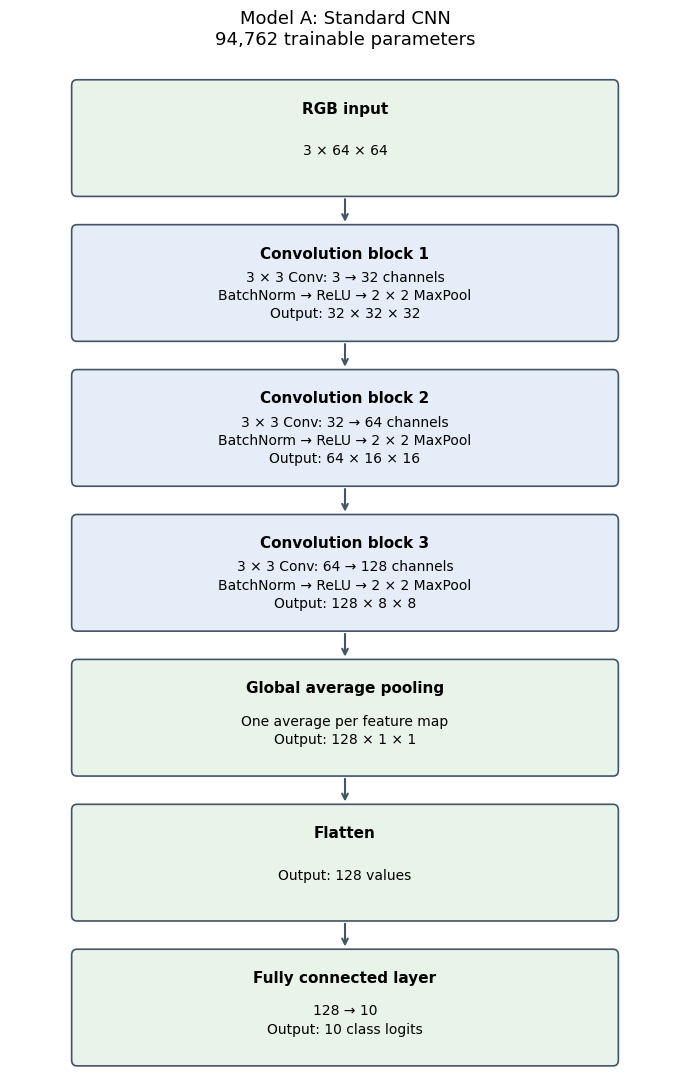

In [15]:
from matplotlib.patches import FancyBboxPatch

# I describe the layers and output shapes of Model A.
stages = [
    ("RGB input", "3 × 64 × 64"),
    (
        "Convolution block 1",
        "3 × 3 Conv: 3 → 32 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 32 × 32 × 32",
    ),
    (
        "Convolution block 2",
        "3 × 3 Conv: 32 → 64 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 64 × 16 × 16",
    ),
    (
        "Convolution block 3",
        "3 × 3 Conv: 64 → 128 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 128 × 8 × 8",
    ),
    (
        "Global average pooling",
        "One average per feature map\nOutput: 128 × 1 × 1",
    ),
    ("Flatten", "Output: 128 values"),
    ("Fully connected layer", "128 → 10\nOutput: 10 class logits"),
]

fig, ax = plt.subplots(figsize=(7, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(stages) * 2)
ax.axis("off")

box_height = 1.45
centres = []

for index, (title, description) in enumerate(stages):
    centre_y = len(stages) * 2 - 1 - index * 2
    centres.append(centre_y)

    colour = "#E5EEF8" if 1 <= index <= 3 else "#E8F3EA"

    box = FancyBboxPatch(
        (1, centre_y - box_height / 2),
        8,
        box_height,
        boxstyle="round,pad=0.08",
        facecolor=colour,
        edgecolor="#425466",
        linewidth=1.2,
    )
    ax.add_patch(box)

    ax.text(
        5, centre_y + 0.40, title,
        ha="center", va="center",
        fontsize=11, fontweight="bold",
    )
    ax.text(
        5, centre_y - 0.18, description,
        ha="center", va="center",
        fontsize=10, linespacing=1.4,
    )

# I connect the blocks in the order used by the forward method.
for upper, lower in zip(centres[:-1], centres[1:]):
    ax.annotate(
        "",
        xy=(5, lower + box_height / 2 + 0.08),
        xytext=(5, upper - box_height / 2 - 0.08),
        arrowprops=dict(
            arrowstyle="->",
            color="#425466",
            linewidth=1.5,
        ),
    )

ax.set_title(
    "Model A: Standard CNN\n94,762 trainable parameters",
    fontsize=13,
    pad=15,
)

plt.tight_layout()
plt.show()